# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [97]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [98]:
import librosa
import warnings

In [99]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [100]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [101]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer
from bat_detect.detector import models
from cfg import get_config
from pipeline import pipeline
from utils.utils import gen_empty_df, convert_df_ravenpro
from bat_detect.utils import wavfile
import bat_detect.utils.detector_utils as du
import bat_detect.detector.compute_features as feats
import bat_detect.detector.post_process as pp

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [102]:
def plot_audio_seg(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()


def plot_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(10, 5))
    plt.rcParams.update({'font.size': 24})
    plt.title(spec_features['plot_title'], fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax)

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 6), 
               labels=np.linspace(0, duration, 6, dtype=plot_xtype).astype(int), rotation=0)
    plt.xlabel("Time (s)")
    plt.twinx(ax=ax)
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")

    plt.show()

In [103]:
def convert_nabatdf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] =  (df['peak_time_ms']-50)/1000
    raven_df['End Time (s)'] = (df['peak_time_ms']-40)/1000
    raven_df['Low Freq (Hz)'] = df['peak_freq_hz']-2000
    raven_df['High Freq (Hz)'] = df['peak_freq_hz']+2000
    raven_df['prediction'] = df['prediction']
    raven_df['score'] = df['score']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_nabatdf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = (df['peak_time_ms']-50)/1000
    bd2_df['end_time'] = (df['peak_time_ms']-40)/1000
    bd2_df['low_freq'] = df['peak_freq_hz']-2000
    bd2_df['high_freq'] = df['peak_freq_hz']+2000
    bd2_df['prediction'] = df['prediction']
    bd2_df['score'] = df['score']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_kaleidoscopedf_to_ravenprodf(df):
    raven_df = pd.DataFrame()
    raven_df['Begin Time (s)'] = df['OFFSET']
    raven_df['End Time (s)'] = df['OFFSET'] + df['DURATION']
    raven_df['Low Freq (Hz)'] = df['Fmin']
    raven_df['High Freq (Hz)'] = df['Fmax']
    raven_df['input_file'] = df['IN FILE']
    raven_df['input_dir'] = df['INDIR']
    raven_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        raven_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        raven_df['TOP1MATCH'] = df['TOP1MATCH']
    raven_df['TOP1DIST'] = df['TOP1DIST']
    raven_df['TOP2MATCH'] = df['TOP2MATCH']
    raven_df['TOP2DIST'] = df['TOP2DIST']
    raven_df['TOP3MATCH'] = df['TOP3MATCH']
    raven_df['TOP3DIST'] = df['TOP3DIST']
    raven_df.sort_values('Begin Time (s)', inplace=True)
    raven_df.insert(0, 'Selection', np.arange(len(raven_df)).astype(int)+1)

    raventxt_df = pd.DataFrame(np.repeat(raven_df.values, 2, axis=0))
    raventxt_df.columns = raven_df.columns
    raventxt_df['Selection'] = raventxt_df['Selection'].astype(int)
    raventxt_df.insert(1, 'Channel', [1]*raventxt_df.shape[0])
    views = np.array(['Waveform 1']*raventxt_df.shape[0], dtype='object')
    views[1::2] = 'Spectrogram 1'
    raventxt_df.insert(1, 'View', views)

    return raventxt_df

def convert_kaleidoscopedf_to_bd2df(df):
    bd2_df = pd.DataFrame()
    bd2_df['start_time'] = df['OFFSET']
    bd2_df['end_time'] = df['OFFSET'] + df['DURATION']
    bd2_df['low_freq'] = df['Fmin']
    bd2_df['high_freq'] = df['Fmax']
    bd2_df['input_file'] = df['IN FILE']
    bd2_df['input_dir'] = df['INDIR']
    bd2_df['mean_freq'] = df['Fmean']
    if 'TOP1MATCH*' in df.columns:
        bd2_df['TOP1MATCH*'] = df['TOP1MATCH*']
    if 'TOP1MATCH' in df.columns:
        bd2_df['TOP1MATCH'] = df['TOP1MATCH']
    bd2_df['TOP1DIST'] = df['TOP1DIST']
    bd2_df['TOP2MATCH'] = df['TOP2MATCH']
    bd2_df['TOP2DIST'] = df['TOP2DIST']
    bd2_df['TOP3MATCH'] = df['TOP3MATCH']
    bd2_df['TOP3DIST'] = df['TOP3DIST']
    bd2_df.sort_values('start_time', inplace=True)
    
    return bd2_df

def convert_raventxtdf_to_bd2df(raventxt_df):
    bd2_human_df = raventxt_df[::2].copy()
    bd2_human_df = bd2_human_df.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq'}, inplace=True)
    bd2_human_df.sort_values('start_time', inplace=True)
    
    return bd2_human_df

## Below are the functions for running the batdetect2 detector with desired threshold

In [130]:
def load_audio_file(audio_file, time_exp_fact, target_samp_rate, scale=False, max_duration=False):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=wavfile.WavFileWarning)
        #sampling_rate, audio_raw = wavfile.read(audio_file)
        audio_raw, sampling_rate = librosa.load(audio_file, sr=None)

    if len(audio_raw.shape) > 1:
        raise Exception('Currently does not handle stereo files')
    sampling_rate = sampling_rate * time_exp_fact

    # resample - need to do this after correcting for time expansion
    sampling_rate_old = sampling_rate
    sampling_rate = target_samp_rate
    audio_raw = librosa.resample(audio_raw, orig_sr=sampling_rate_old, target_sr=sampling_rate, res_type='polyphase')

    # clipping maximum duration
    if max_duration is not False:
        max_duration = np.minimum(int(sampling_rate*max_duration), audio_raw.shape[0])
        audio_raw = audio_raw[:max_duration]
        
    # convert to float32 and scale
    audio_raw = audio_raw.astype(np.float32)
    if scale:
        audio_raw = audio_raw - audio_raw.mean()
        audio_raw = audio_raw / (np.abs(audio_raw).max() + 10e-6)

    return sampling_rate, audio_raw

def run_detector_on_audio_data(model, args, params, audio_full, plot_file, sampling_rate):
    # store temporary results here
    predictions = []
    spec_feats  = []
    cnn_feats   = []
    spec_slices = []

    # get time expansion  factor
    time_exp = args['time_expansion_factor']

    params['detection_threshold'] = args['detection_threshold']
    top_n=5
    # clipping maximum duration
    duration_full = audio_full.shape[0] / float(sampling_rate)

    return_np_spec = args['spec_features'] or args['spec_slices']

    # loop through larger file and split into chunks
    # TODO fix so that it overlaps correctly and takes care of duplicate detections at borders
    num_chunks = int(np.ceil(duration_full/args['chunk_size']))
    for chunk_id in tqdm(range(num_chunks)):
        # chunk
        chunk_time   = args['chunk_size']*chunk_id
        chunk_length = int(sampling_rate*args['chunk_size'])
        start_sample = chunk_id*chunk_length
        end_sample   = np.minimum((chunk_id+1)*chunk_length, audio_full.shape[0])
        audio = audio_full[start_sample:end_sample]

        # load audio file and compute spectrogram
        duration, spec, spec_np = du.compute_spectrogram(audio, sampling_rate, params, return_np_spec)

        # evaluate model
        with torch.no_grad():
            outputs = model(spec, return_feats=args['cnn_features'])

        # run non-max suppression
        pred_nms, features = pp.run_nms(outputs, params, np.array([float(sampling_rate)]))
        pred_nms = pred_nms[0]
        pred_nms['start_times'] += chunk_time
        pred_nms['end_times'] += chunk_time

        # if we have a background class
        if pred_nms['class_probs'].shape[0] > len(params['class_names']):
            pred_nms['class_probs'] = pred_nms['class_probs'][:-1, :]

        predictions.append(pred_nms)

        # extract features - if there are any calls detected
        if (pred_nms['det_probs'].shape[0] > 0):
            if args['spec_features']:
                spec_feats.append(feats.get_feats(spec_np, pred_nms, params))

            if args['cnn_features']:
                cnn_feats.append(features[0])

            if args['spec_slices']:
                spec_slices.extend(feats.extract_spec_slices(spec_np, pred_nms, params))

    # convert the predictions into output dictionary
    file_id = plot_file.name
    predictions, spec_feats, cnn_feats, spec_slices =\
                du.merge_results(predictions, spec_feats, cnn_feats, spec_slices)
    results = du.convert_results(file_id, time_exp, duration_full, params,
                                predictions, spec_feats, cnn_feats, spec_slices)

    # summarize results
    if not args['quiet']:
        num_detections = len(results['pred_dict']['annotation'])
        print('{}'.format(num_detections) + ' call(s) detected above the threshold.')

    # print results for top n classes
    if not args['quiet'] and (num_detections > 0):
        class_overall = pp.overall_class_pred(predictions['det_probs'], predictions['class_probs'])
        print('species name'.ljust(30) + 'probablity present')
        for cc in np.argsort(class_overall)[::-1][:top_n]:
            print(params['class_names'][cc].ljust(30) + str(round(class_overall[cc], 3)))

    annotations = results['pred_dict']['annotation']
    out_df = gen_empty_df()
    if annotations:
        out_df = pd.DataFrame.from_records(annotations) 

    return out_df

In [131]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net_params = torch.load('../src/models/bat_call_detector/batdetect2/models/Net2DFast_UK_same.pth.tar', map_location=device)
params = net_params['params']
params['device'] = device
model = models.Net2DFast(params['num_filters'], num_classes=len(params['class_names']),
                            emb_dim=params['emb_dim'], ip_height=params['ip_height'],
                            resize_factor=params['resize_factor'])
model.load_state_dict(net_params['state_dict'])
model = model.to(params['device'])
model.eval()

Net2DFast(
  (conv_dn_0): ConvBlockDownCoordF(
    (conv): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_dn_1): ConvBlockDownCoordF(
    (conv): Conv2d(33, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_dn_2): ConvBlockDownCoordF(
    (conv): Conv2d(65, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv_bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_dn_3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_dn_3_bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_1d): Conv2d(256, 256, kernel_size=(16, 1), stride=(1, 1))
  (conv_1d_bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (a

In [132]:
wav_filename = '20220826_070000'
site = 'Central'
plot_file = Path(f'../../Documents/{wav_filename}/input/{wav_filename}.WAV')
resampling_rate, audio_data_resampled = load_audio_file(plot_file, 1, 256000)

In [ ]:
for thresh in np.arange(0.02, 1.0, 0.02):
    args = dict()
    args['time_expansion_factor'] = 1.0
    args['detection_threshold'] = round(thresh,2)
    args['chunk_size'] = 3
    args['spec_slices'] = False
    args['quiet'] = False
    args['spec_features'] = False
    args['cnn_features'] = True
    threshold_tag = f"threshold{str(args['detection_threshold']).replace('.','p')}"
    print(args['detection_threshold'], str(args['detection_threshold']), threshold_tag)
    save_dir = Path(f'bd2__det_thresh_sweep_{wav_filename}')
    save_loc = Path(f"bd2__{threshold_tag}_chunksize{args['chunk_size']}_{plot_file.name.split('.')[0]}.csv")
    print("saving to", (save_dir/save_loc))
    if not(save_dir.exists()):
        save_dir.mkdir()
    if not((save_dir/save_loc).exists()):
        batdetect2_df_mod = run_detector_on_audio_data(model, args, params, audio_data_resampled, plot_file, resampling_rate)
        batdetect2_df_mod.to_csv((save_dir/save_loc))
    else:
        batdetect2_df_mod = pd.read_csv((save_dir/save_loc), sep=',')

In [121]:
kaleido_df = pd.read_csv(f'../../Documents/{wav_filename}/output/cluster.csv')
bd2_kaleido_df = convert_kaleidoscopedf_to_bd2df(kaleido_df)
bd2_kaleido_df

,start_time,end_time,low_freq,high_freq,input_file,input_dir,mean_freq,TOP1MATCH*,TOP1DIST,TOP2MATCH,TOP2DIST,TOP3MATCH,TOP3DIST
0,4.851936,4.854150,49390.242,57189.543,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,52390.625,nocluster,0,NaN,0,NaN,0
1,5.005365,5.006396,45977.012,47619.047,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,46551.992,nocluster,0,NaN,0,NaN,0
2,5.785726,5.786784,47905.906,51615.051,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,49152.609,nocluster,0,NaN,0,NaN,0
3,38.635807,38.641656,25236.844,27118.957,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,25987.514,nocluster,0,NaN,0,NaN,0
4,39.376575,39.379396,25157.232,26144.906,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,25527.117,nocluster,0,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,1776.757446,1776.759058,41026.719,45199.184,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,42182.492,nocluster,0,NaN,0,NaN,0
556,1776.854004,1776.855824,40004.000,44200.242,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,41756.090,nocluster,0,NaN,0,NaN,0
557,1777.039062,1777.042574,39230.770,44200.242,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,40997.746,nocluster,0,NaN,0,NaN,0
558,1777.271484,1777.272512,42109.930,44444.445,20220826_070000.WAV,/Users/adityakrishna/Documents/20220826_070000...,42786.316,nocluster,0,NaN,0,NaN,0


In [122]:
batdetect2_df = pd.read_csv(f'../../duty-cycle-investigation/data/raw/{site}/bd2__{site}_{wav_filename}.csv', sep=',')
batdetect2_df

,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file,Recover Folder,SD Card,Site name
0,3.7705,3.7771,45234.0,54096.0,Pipistrellus pipistrellus,0.466,0.512,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
1,4.3085,4.3140,46093.0,59238.0,Pipistrellus pipistrellus,0.512,0.542,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
2,4.8505,4.8558,45234.0,62030.0,Pipistrellus pipistrellus,0.427,0.524,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
3,5.0035,5.0094,45234.0,60073.0,Pipistrellus pipistrellus,0.489,0.538,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
4,5.1515,5.1569,46093.0,61459.0,Pipistrellus pipistrellus,0.439,0.517,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,1787.7745,1787.7849,37500.0,46675.0,Pipistrellus nathusii,0.492,0.587,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
1593,1787.9595,1787.9694,37500.0,45913.0,Pipistrellus nathusii,0.537,0.591,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
1594,1788.2125,1788.2212,39218.0,48186.0,Pipistrellus nathusii,0.431,0.544,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
1595,1788.4135,1788.4225,40078.0,49982.0,Pipistrellus nathusii,0.441,0.566,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond


In [123]:
raventxt_human_df = pd.read_csv(f'../../Documents/Research/mila_files/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK.txt', sep='\t')
bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
bd2_human_df.reset_index(inplace=True, drop=True)
bd2_human_df

,start_time,end_time,low_freq,high_freq,Annotation,detection_confidence,input_file
0,3.770500,3.777100,45234.000,54096.000,Echolocation,0.512,20220826_070000.WAV
1,3.911402,3.918947,43903.720,56927.790,AK_echolocation,NaN,NaN
2,4.161126,4.170934,43903.720,56507.659,AK_echolocation,NaN,NaN
3,4.308500,4.314000,46093.000,59238.000,Echolocation,0.542,20220826_070000.WAV
4,4.440252,4.452032,42018.237,53398.176,e,NaN,NaN
...,...,...,...,...,...,...,...
4122,1787.774500,1787.784900,37500.000,46675.000,Echolocation,0.587,20220826_070000.WAV
4123,1787.959500,1787.969400,37500.000,45913.000,Echolocation,0.591,20220826_070000.WAV
4124,1788.212500,1788.221200,39218.000,48186.000,Echolocation,0.544,20220826_070000.WAV
4125,1788.413500,1788.422500,40078.000,49982.000,Echolocation,0.566,20220826_070000.WAV


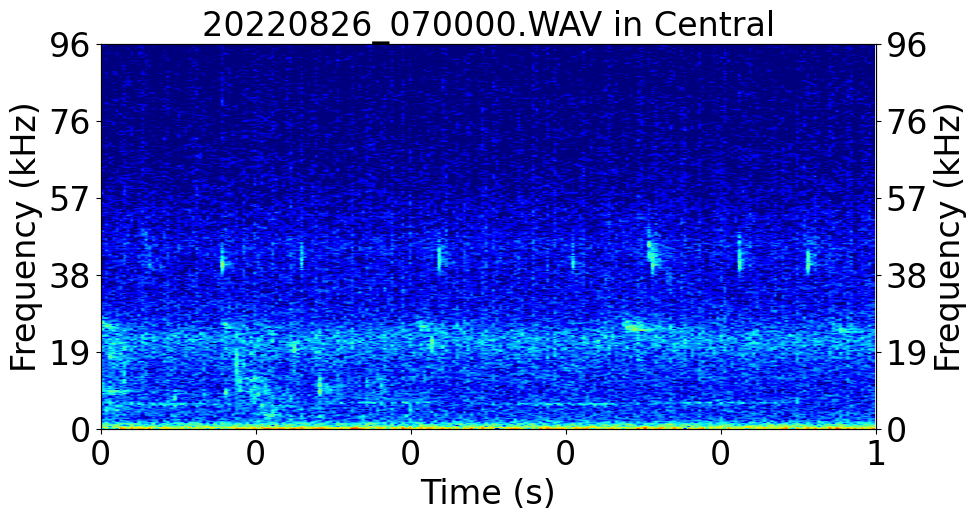

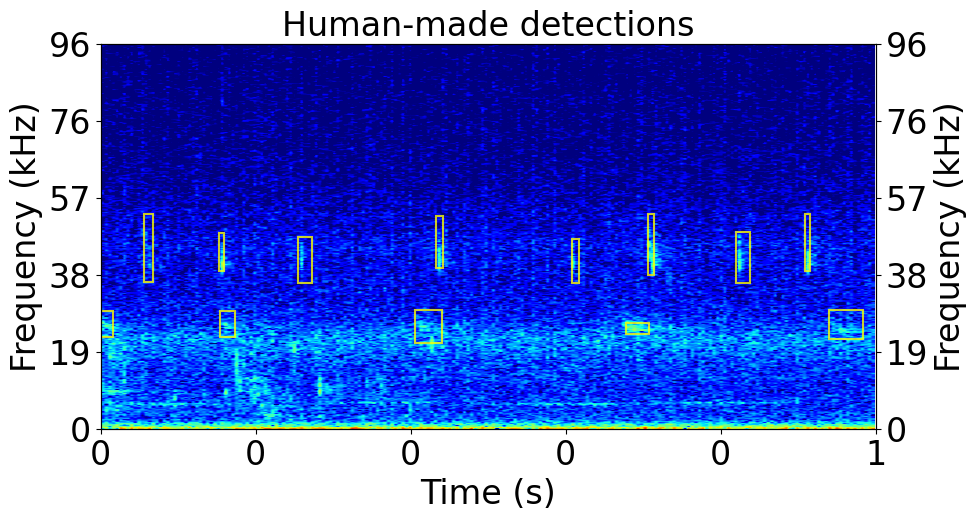

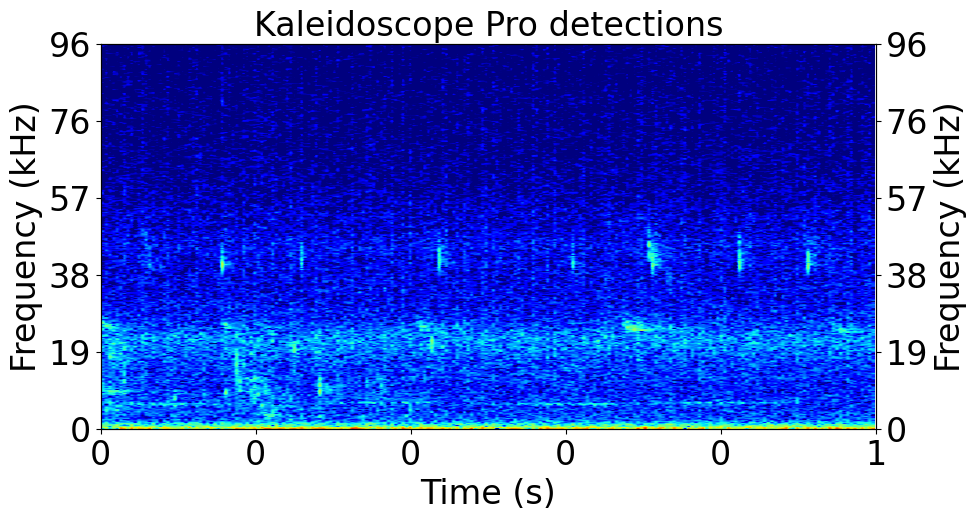

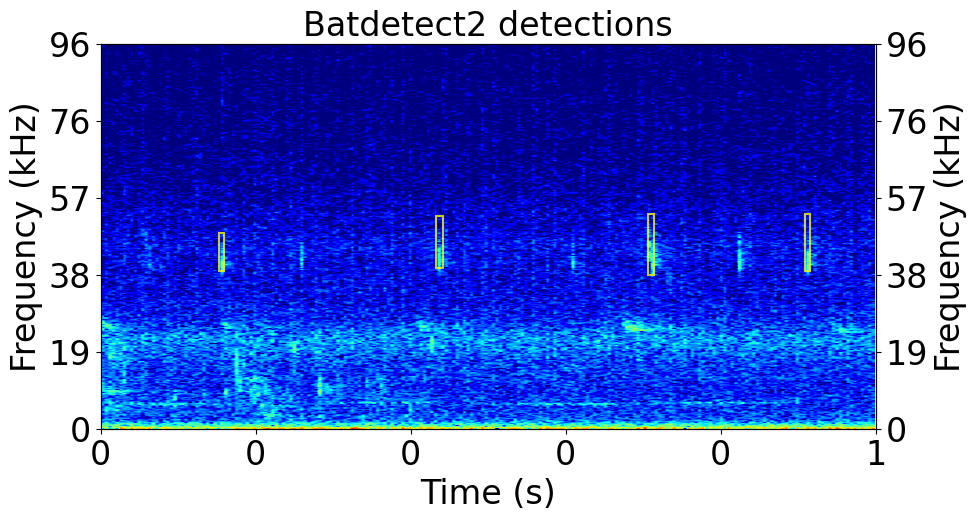

In [124]:
# Below we filter our detections dataframe to only get the detections corresponding to the above audio file
audio_file = sf.SoundFile(plot_file)
fs = audio_file.samplerate
start = 366
duration = 1
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmin = -60
vmax = 0
audio_features = dict()
audio_features['file_path'] = Path(plot_file)
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax


spec_features['plot_title'] = f"{audio_features['file_path'].name} in {site}"
plot_dets_over_audio(audio_features, spec_features, pd.DataFrame())
spec_features['plot_title'] = f"Human-made detections"
plot_dets_over_audio(audio_features, spec_features, bd2_human_df)
spec_features['plot_title'] = f"Kaleidoscope Pro detections"
plot_dets_over_audio(audio_features, spec_features, bd2_kaleido_df)
spec_features['plot_title'] = f"Batdetect2 detections"
plot_dets_over_audio(audio_features, spec_features, batdetect2_df)

In [125]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]

        machine_det_start_in_human_det_bounds = ((machine_det['start_time']>=human_det['start_time'])&(machine_det['start_time']<=human_det['end_time']))
        machine_det_end_in_human_det_bounds = ((machine_det['end_time']>=human_det['start_time'])&(machine_det['end_time']<=human_det['end_time']))
        human_det_start_in_machine_det_bounds = ((human_det['start_time']>=machine_det['start_time'])&(human_det['start_time']<=machine_det['end_time']))
        human_det_end_in_machine_det_bounds = ((human_det['end_time']>=machine_det['start_time'])&(human_det['end_time']<=machine_det['end_time']))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_det['low_freq']>=human_det['low_freq'])&(machine_det['low_freq']<=human_det['high_freq']))
        machine_det_high_in_human_det_bounds = ((machine_det['high_freq']>=human_det['low_freq'])&(machine_det['high_freq']<=human_det['high_freq']))
        human_det_low_in_machine_det_bounds = ((human_det['low_freq']>=machine_det['low_freq'])&(human_det['low_freq']<=machine_det['high_freq']))
        human_det_high_in_machine_det_bounds = ((human_det['high_freq']>=machine_det['low_freq'])&(human_det['high_freq']<=machine_det['high_freq']))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        # print(human_ind, machine_ind, true_positives, false_positives, 
        #       false_negatives, true_negatives, machine_det_time_matches_human_time,
        #       machine_det_freq_matches_human_time)

        if (machine_detection_corresponds_to_human):
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_det['end_time']<human_det['start_time'])&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_det['start_time']<human_det['start_time'])&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_det['start_time']>human_det['end_time'])&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_det['start_time']>human_det['start_time'])&(~machine_det_freq_matches_human_time)
            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))

    return {'true_positives':true_positives, 'false_positives':false_positives, 'false_negatives':false_negatives, 'true_negatives':true_negatives}

In [126]:
plot_bd2_human_df = bd2_human_df[(bd2_human_df['start_time']>=start)&(bd2_human_df['end_time']<=(start+duration))].reset_index(drop=True)
plot_bd2_human_df

,start_time,end_time,low_freq,high_freq,Annotation,detection_confidence,input_file
0,366.055903,366.067974,36682.927,53593.496,AK_echolocation,NaN,NaN
1,366.152500,366.159600,39218.000,48824.000,Echolocation,0.537,20220826_070000.WAV
2,366.153982,366.173598,22894.309,29398.374,AK_echolocation,NaN,NaN
3,366.254380,366.272050,36292.683,47707.317,v,NaN,NaN
4,366.405246,366.439951,21333.333,29658.537,AK_echolocation,NaN,NaN
5,366.432500,366.441000,40078.000,52981.000,Echolocation,0.502,20220826_070000.WAV
6,366.607783,366.616618,36292.683,47414.634,v,NaN,NaN
7,366.677860,366.707311,23707.317,26341.463,v,NaN,NaN
8,366.705500,366.713800,38359.000,53644.000,Echolocation,0.610,20220826_070000.WAV
9,366.819825,366.837495,36292.683,49170.732,e,NaN,NaN


In [127]:
plot_batdetect2_df = batdetect2_df[(batdetect2_df['start_time']>=start)&(batdetect2_df['end_time']<=(start+duration))].reset_index(drop=True)
plot_batdetect2_df

,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file,Recover Folder,SD Card,Site name
0,366.1525,366.1596,39218.0,48824.0,Pipistrellus nathusii,0.461,0.537,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
1,366.4325,366.4410,40078.0,52981.0,Pipistrellus nathusii,0.466,0.502,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
2,366.7055,366.7138,38359.0,53644.0,Pipistrellus nathusii,0.480,0.610,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond
3,366.9085,366.9153,39218.0,53426.0,Pipistrellus nathusii,0.483,0.539,-1,Echolocation,/mnt/ubna_data_01/recover-20220828/UBNA_010/20...,recover-20220828,UBNA_010,Central Pond


In [128]:
return_confusion_matrix_from_comparing_two_detectors(plot_bd2_human_df, plot_batdetect2_df)

{'true_positives': 4,
 'false_positives': 0,
 'false_negatives': 8,
 'true_negatives': 0}

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [113]:
return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, bd2_kaleido_df)

{'true_positives': 545,
 'false_positives': 15,
 'false_negatives': 3582,
 'true_negatives': 0}

In [114]:
return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df)

{'true_positives': 1597,
 'false_positives': 0,
 'false_negatives': 2530,
 'true_negatives': 0}

In [115]:
file_sites = {'20220730_053000':'Carp',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage',
 '20220826_070000':'Central'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220727_083000', '20220829_090000', '20220826_070000']

In [117]:
kaleido_cf_matrices = {'true_positives':0, 'false_positives':0, 'false_negatives':0, 'true_negatives':0}
batdetect2_cf_matrices = {'true_positives':0, 'false_positives':0, 'false_negatives':0, 'true_negatives':0}

for file_key in file_keys:
    wav_filename = file_key
    site = file_sites[file_key]
    print(wav_filename, site)

    kaleido_df = pd.read_csv(f'../../Documents/{wav_filename}/output/cluster.csv')
    bd2_kaleido_df = convert_kaleidoscopedf_to_bd2df(kaleido_df)

    raventxt_human_df = pd.read_csv(f'../../Documents/Research/mila_files/mila-human-wav-txt/{wav_filename}_manually_verified_by_AK.txt', sep='\t')
    bd2_human_df = convert_raventxtdf_to_bd2df(raventxt_human_df)
    bd2_human_df.reset_index(inplace=True, drop=True)

    batdetect2_df = pd.read_csv(f'../../duty-cycle-investigation/data/raw/{site}/bd2__{site}_{wav_filename}.csv', sep=',')

    print('Kaleidoscope confusion matrix')
    file_kaleido_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, bd2_kaleido_df)
    print(file_kaleido_cf)
    kaleido_cf_matrices['true_positives'] += file_kaleido_cf['true_positives']
    kaleido_cf_matrices['false_positives'] += file_kaleido_cf['false_positives']
    kaleido_cf_matrices['false_negatives'] += file_kaleido_cf['false_negatives']
    kaleido_cf_matrices['true_negatives'] += file_kaleido_cf['true_negatives']

    print('Batdetect2 confusion matrix')
    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df)
    print(file_batdetect2_cf)
    batdetect2_cf_matrices['true_positives'] += file_batdetect2_cf['true_positives']
    batdetect2_cf_matrices['false_positives'] += file_batdetect2_cf['false_positives']
    batdetect2_cf_matrices['false_negatives'] += file_batdetect2_cf['false_negatives']
    batdetect2_cf_matrices['true_negatives'] += file_batdetect2_cf['true_negatives']

20220730_053000 Carp
Kaleidoscope confusion matrix
{'true_positives': 82, 'false_positives': 0, 'false_negatives': 724, 'true_negatives': 0}
Batdetect2 confusion matrix
{'true_positives': 344, 'false_positives': 0, 'false_negatives': 462, 'true_negatives': 0}
20220727_083000 Foliage
Kaleidoscope confusion matrix
{'true_positives': 1, 'false_positives': 0, 'false_negatives': 172, 'true_negatives': 0}
Batdetect2 confusion matrix
{'true_positives': 23, 'false_positives': 0, 'false_negatives': 150, 'true_negatives': 0}
20220829_090000 Foliage
Kaleidoscope confusion matrix
{'true_positives': 19, 'false_positives': 0, 'false_negatives': 141, 'true_negatives': 0}
Batdetect2 confusion matrix
{'true_positives': 38, 'false_positives': 0, 'false_negatives': 122, 'true_negatives': 0}
20220826_070000 Central
Kaleidoscope confusion matrix
{'true_positives': 545, 'false_positives': 15, 'false_negatives': 3582, 'true_negatives': 0}
Batdetect2 confusion matrix
{'true_positives': 1597, 'false_positives'

In [118]:
kaleido_cf_matrices

{'true_positives': 647,
 'false_positives': 15,
 'false_negatives': 4619,
 'true_negatives': 0}

In [119]:
batdetect2_cf_matrices

{'true_positives': 2002,
 'false_positives': 0,
 'false_negatives': 3264,
 'true_negatives': 0}